Saving PolynomialData.csv to PolynomialData.csv
Dataset:


,X,Y
0,0.000000,5.609434
1,0.050251,3.075836
2,0.100503,6.822611
3,0.150754,7.378844
4,0.201005,1.781751



Linear Regression
MSE: 182.40100866057628
R²: 0.9510199428986829

Polynomial Regression
MSE: 2.9306839990525755
R²: 0.999213024803571


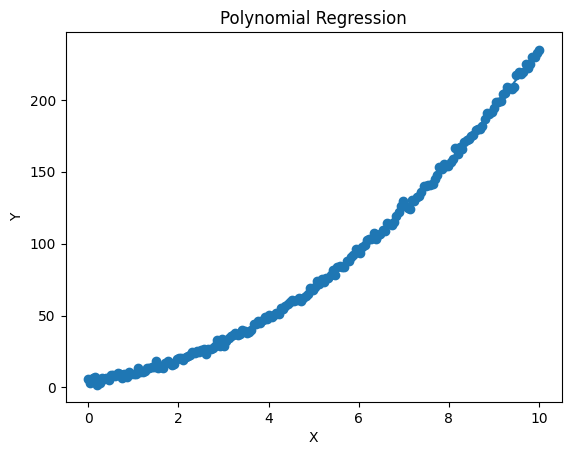

In [1]:
# EXPERIMENT 9: LINEAR VS POLYNOMIAL REGRESSION

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Upload CSV
uploaded = files.upload()

# Read CSV
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset:")
display(df.head())

# Features and target
X = df[["X"]]
y = df["Y"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Linear Regression
# -----------------------------

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

# -----------------------------
# Polynomial Regression
# -----------------------------

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

poly_mse = mean_squared_error(y_test, poly_pred)
poly_r2 = r2_score(y_test, poly_pred)

# Results
print("\nLinear Regression")
print("MSE:", linear_mse)
print("R²:", linear_r2)

print("\nPolynomial Regression")
print("MSE:", poly_mse)
print("R²:", poly_r2)

# Visualization
plt.scatter(X, y)

sorted_X = sorted(X["X"])

sorted_X_df = pd.DataFrame({"X": sorted_X})

plt.plot(
    sorted_X,
    poly_model.predict(poly.transform(sorted_X_df))
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")

plt.show()